# Imports

In [136]:
import sys
import time
import numpy as np
from siriuspy.devices import SOFB, HLFOFB, APU, CurrInfoSI
from siriuspy.devices import APU, VPU
import time
from siriuspy.clientconfigdb import ConfigDBClient
import epics
from mathphys.functions import save, load
import h5py
import os
import threading
import matplotlib.pyplot as plt

# Enviroment definitions

In [125]:
os.environ['EPICS_CA_ADDR_LIST'] += ' 10.39.50.33 10.39.50.34'  # Add IPs of EPICS servers of XBPMs

# Class and functions definitions

## XBPMs class

In [126]:
class xbpmMNC:
    def __init__(self, xbpm_nr=1):
        self.prefix = 'SI-09SAFE:DI-PBPM-' + str(xbpm_nr)

    def ampA(self):
        return epics.caget(self.prefix + ':AmplA-Mon'), 0

    def ampB(self):
        return epics.caget(self.prefix + ':AmplB-Mon'), 0

    def ampC(self):
        return epics.caget(self.prefix + ':AmplC-Mon'), 0

    def ampD(self):
        return epics.caget(self.prefix + ':AmplD-Mon'), 0

    def rangeA(self):
        return 0

    def rangeB(self):
        return 0

    def rangeC(self):
        return 0

    def rangeD(self):
        return 0
    
    def saturatedA(self):
        return 0
    
    def saturatedB(self):
        return 0
    
    def saturatedC(self):
        return 0
    
    def saturatedD(self):
        return 0


class xbpmMGN:
    def __init__(self, xbpm_nr=1):
        self.prefix = 'SI-10BCFE:DI-PBPM-' + str(xbpm_nr)

    def ampA(self):
        return epics.caget(self.prefix + ':AmplA-Mon'), 0

    def ampB(self):
        return epics.caget(self.prefix + ':AmplB-Mon'), 0

    def ampC(self):
        return epics.caget(self.prefix + ':AmplC-Mon'), 0

    def ampD(self):
        return epics.caget(self.prefix + ':AmplD-Mon'), 0

    def rangeA(self):
        return 0

    def rangeB(self):
        return 0

    def rangeC(self):
        return 0

    def rangeD(self):
        return 0
    
    def saturatedA(self):
        return 0
    
    def saturatedB(self):
        return 0
    
    def saturatedC(self):
        return 0
    
    def saturatedD(self):
        return 0


class xbpmCAT:
    def __init__(self, xbpm_nr=1):
        self.prefix = 'CAT:FE:PICO01'

    def ampA(self):
        return epics.caget(self.prefix + ':Current1:EngValue'), epics.caget(
            self.prefix + ':Current1:EngUnit'
        )

    def ampB(self):
        return epics.caget(self.prefix + ':Current2:EngValue'), epics.caget(
            self.prefix + ':Current2:EngUnit'
        )

    def ampC(self):
        return epics.caget(self.prefix + ':Current3:EngValue'), epics.caget(
            self.prefix + ':Current3:EngUnit'
        )

    def ampD(self):
        return epics.caget(self.prefix + ':Current4:EngValue'), epics.caget(
            self.prefix + ':Current4:EngUnit'
        )

    def rangeA(self):
        return epics.caget(self.prefix + ':Current1:Range_RBV')

    def rangeB(self):
        return epics.caget(self.prefix + ':Current2:Range_RBV')

    def rangeC(self):
        return epics.caget(self.prefix + ':Current3:Range_RBV')

    def rangeD(self):
        return epics.caget(self.prefix + ':Current4:Range_RBV')

    def saturatedA(self):
        return 0
    
    def saturatedB(self):
        return 0
    
    def saturatedC(self):
        return 0
    
    def saturatedD(self):
        return 0


class xbpmCNB:
    def __init__(self, xbpm_nr=1):
        self.prefix = 'CNB:FE:PICO01'

    def ampA(self):
        return epics.caget(self.prefix + ':Current1:EngValue'), epics.caget(
            self.prefix + ':Current1:EngUnit'
        )

    def ampB(self):
        return epics.caget(self.prefix + ':Current2:EngValue'), epics.caget(
            self.prefix + ':Current2:EngUnit'
        )

    def ampC(self):
        return epics.caget(self.prefix + ':Current3:EngValue'), epics.caget(
            self.prefix + ':Current3:EngUnit'
        )

    def ampD(self):
        return epics.caget(self.prefix + ':Current4:EngValue'), epics.caget(
            self.prefix + ':Current4:EngUnit'
        )

    def rangeA(self):
        return epics.caget(self.prefix + ':Current1:Range_RBV')

    def rangeB(self):
        return epics.caget(self.prefix + ':Current2:Range_RBV')

    def rangeC(self):
        return epics.caget(self.prefix + ':Current3:Range_RBV')

    def rangeD(self):
        return epics.caget(self.prefix + ':Current4:Range_RBV')

    def saturatedA(self):
        return epics.caget(self.prefix + ':Current1:Saturated')
    
    def saturatedB(self):
        return epics.caget(self.prefix + ':Current2:Saturated')
    
    def saturatedC(self):
        return epics.caget(self.prefix + ':Current3:Saturated')
    
    def saturatedD(self):
        return epics.caget(self.prefix + ':Current4:Saturated')


## Undulators functions

In [127]:
def move_vpu_gap(vpu: VPU, gap, timeout, verbose=False):
    vpu.set_gap(gap)
    time.sleep(0.5)
    print('Gap-RB {:.3f} mm'.format(vpu.gap)) if verbose else 0
    if vpu.cmd_move_start(timeout):
        time.sleep(0.5)
        print('Undulator is moving...') if verbose else 0
        while vpu.is_moving:
            time.sleep(0.1)
            print('Current gap {:.3f} mm.'.format(vpu.gap_mon), end='\r') if verbose else 0
        print('Gap {:.3f} mm reached.'.format(vpu.gap)) if verbose else 0
        return True
    else:
        print('Error while cmd_move_start.')
        return False

def move_apu_phase(apu: APU, phase, timeout, verbose=False):
    apu.set_phase(phase)
    time.sleep(0.5)
    print('phase-RB {:.3f} mm'.format(apu.phase)) if verbose else 0
    if apu.cmd_move_start(timeout):
        time.sleep(0.5)
        print('Undulator is moving...') if verbose else 0
        while apu.is_moving:
            time.sleep(0.1)
            print('Current phase {:.3f} mm.'.format(apu.phase_mon), end='\r') if verbose else 0
        print('phase {:.3f} mm reached.'.format(apu.phase)) if verbose else 0
        return True
    else:
        print('Error while cmd_move_start.')
        return False

## Measurement algorithm functions

In [200]:
def meas(
    idlist,
    xbpmlist,
    names,
    sofb: SOFB,
    currinfo: CurrInfoSI,
    subsec='09SA',
    agx=0,
    agy=0,
    psx=0,
    psy=0,
    nr_meas=10,
    tinterval=1,
):
    blades = dict()
    for i, xbpm in enumerate(xbpmlist):
        blades[names[i]] = {
            'prefix': xbpm.prefix,
            'A_val': [],
            'B_val': [],
            'C_val': [],
            'D_val': [],
            'A_range': [],
            'B_range': [],
            'C_range': [],
            'D_range': [],
            'A_saturation': [],
            'B_saturation': [],
            'C_saturation': [],
            'D_saturation': [],
        }

    for j in np.arange(nr_meas):
        for i, xbpm in enumerate(xbpmlist):
            xbpm_ampA = xbpm.ampA()
            xbpm_ampB = xbpm.ampB()
            xbpm_ampC = xbpm.ampC()
            xbpm_ampD = xbpm.ampD()
            
            xbpm_rangeA = xbpm.rangeA()
            xbpm_rangeB = xbpm.rangeB()
            xbpm_rangeC = xbpm.rangeC()
            xbpm_rangeD = xbpm.rangeD()

            xbpm_satA = xbpm.saturatedA()
            xbpm_satB = xbpm.saturatedB()
            xbpm_satC = xbpm.saturatedC()
            xbpm_satD = xbpm.saturatedD()

            blades[names[i]]['A_val'].append(xbpm_ampA)
            blades[names[i]]['B_val'].append(xbpm_ampB)
            blades[names[i]]['C_val'].append(xbpm_ampC)
            blades[names[i]]['D_val'].append(xbpm_ampD)

            blades[names[i]]['A_range'].append(xbpm_rangeA)
            blades[names[i]]['B_range'].append(xbpm_rangeB)
            blades[names[i]]['C_range'].append(xbpm_rangeC)
            blades[names[i]]['D_range'].append(xbpm_rangeD)

            blades[names[i]]['A_saturation'].append(xbpm_satA)
            blades[names[i]]['B_saturation'].append(xbpm_satB)
            blades[names[i]]['C_saturation'].append(xbpm_satC)
            blades[names[i]]['D_saturation'].append(xbpm_satD)
        time.sleep(tinterval)

    apu_mnc = idlist[0]
    vpu_cnb = idlist[1]
    vpu_cat = idlist[2]

    idinfo = {
        'cnb': vpu_cnb.gap_mon,
        'cat': vpu_cat.gap_mon,
        'mnc': apu_mnc.phase_mon,
    }

    machinfo = {
        'current': currinfo.current,
        'agx': agx,
        'agy': agy,
        'posx': psx,
        'posy': psy,
        'orbx': sofb.orbx,
        'orby': sofb.orby,
    }

    data = (blades, idinfo, machinfo)

    fname = 'xbpm_acq_subsec:'
    fname += f'{subsec}_agx:{agx:03.0f}_agy:{agy:03.0f}_'
    fname += f'posx:{psx:03.0f}_posy:{psy:03.0f}_'
    fname += 'time_' + str(time.time()) + '.pickle'
    save(data, fname)

    return data


def implement_bump(
    sofb: SOFB=None,
    # fofb: HLFOFB=None,
    subsec='09SA',
    refx=None,
    refy=None,
    agx=0,
    agy=0,
    psx=0,
    psy=0,
    tol_orb=1,
    bpmxenbl_sofb=None,
    bpmyenbl_sofb=None,
    # bpmxenbl_fofb=None,
    # bpmyenbl_fofb=None,
):
    def get_rms(refx, refy, idx):
        dorbx = sofb.orbx - refx
        dorby = sofb.orby - refy
        dorbx = dorbx[idx]
        dorby = dorby[idx]
        return np.hstack([dorbx, dorby]).std()

    max_tol_orb = 50

    # Get ref orb
    if refx is None or refy is None:
        clt = ConfigDBClient(config_type='si_orbit')
        ref_orb = clt.get_config_value('ref_orb')
        refx = np.array(ref_orb['x'])
        refy = np.array(ref_orb['y'])

    # Calculate bumps
    orbx, orby = sofb.si_calculate_bumps(
        refx, refy, subsec=subsec, agx=agx, agy=agy, psx=psx, psy=psy
    )

    max_dorbx = np.max(np.abs(orbx - sofb.refx))
    max_dorby = np.max(np.abs(orby - sofb.refy))

    if max(max_dorbx, max_dorby) > 10:
        # fofb.cmd_turn_off_loop_state()


        # fofb.cmd_turn_on_loop_state()
        print(f'Dorb max: {max(max_dorbx, max_dorby)} um')
        pass

    # Find out where bump is being made
    dummy, _ = sofb.si_calculate_bumps(refx, refy, subsec=subsec, agx=10)
    idx = ~np.isclose(dummy, refx)
    strt = idx.nonzero()[0][0]

    # Set orbit on SOFB
    sofb.refx = orbx
    sofb.refy = orby

    # Set orbit on FOFB
    # fofb.refx = orbx
    # fofb.refy = orby

    nr_bpms = 4
    enbl = np.zeros(bpmxenbl_sofb.size, dtype=bool)
    enbl[strt - nr_bpms : strt] = True
    enbl[strt + 2 : strt + 2 + nr_bpms] = True

    xenbl_sofb = bpmxenbl_sofb.copy()
    yenbl_sofb = bpmyenbl_sofb.copy()
    xenbl_sofb[enbl] = False
    yenbl_sofb[enbl] = False
    sofb.bpmxenbl = xenbl_sofb
    sofb.bpmyenbl = yenbl_sofb



    # xenbl_fofb = bpmxenbl_fofb.copy()
    # yenbl_fofb = bpmyenbl_fofb.copy()
    # xenbl_fofb[enbl] = False
    # yenbl_fofb[enbl] = False
    # fofb.bpmxenbl = xenbl_fofb
    # fofb.bpmyenbl = yenbl_fofb

    # Verify orbit correction
    rms_residue = tol_orb+1
    nr_iters = 20
    print('Waiting orbit...')
    for i in range(nr_iters):
        # _ = sofb.correct_orbit_manually(nr_iters=nr_iters, residue=1)
        rms_residue = get_rms(orbx, orby, idx)
        print(f'    rms_residue = {rms_residue:.3f} um')
        if rms_residue <= tol_orb:
            break
        if rms_residue > max_tol_orb:
            raise ValueError('Could not correct orbit.')
        time.sleep(1.5)
    else:
        raise ValueError('Could not correct orbit.')

    print('Done!')


def restore_sofb_reforb(sofb, bpmxenbl, bpmyenbl):
    
    clt = ConfigDBClient(config_type='si_orbit')
    ref_orb = clt.get_config_value('ref_orb')
    refx = np.array(ref_orb['x'])
    refy = np.array(ref_orb['y'])
    sofb.refx = refx
    sofb.refy = refy
    sofb.bpmxenbl = bpmxenbl
    sofb.bpmyenbl = bpmyenbl


def is_beam_alive(currinfo, sofb, idlist, bpmxenbl=None, bpmyenbl=None):
    if currinfo.storedbeam:
        return True
    print('Beam is dead!')
    restore_sofb_reforb(sofb, bpmxenbl, bpmyenbl)
    move_apu_phase(idlist[1], 11)
    move_vpu_gap(idlist[0], 80)
    return False


def stop_meas_func(sofb, idlist, bpmxenbl=None, bpmyenbl=None):
    if not stop_meas:
        return False
    restore_sofb_reforb(sofb, bpmxenbl, bpmyenbl)
    sofb.correct_orbit_manually(10, 2)
    move_apu_phase(idlist[1], 11)
    move_vpu_gap(idlist[0], 80)
    return True


def do_bumps(
    angsx,
    angsy,
    subsec,
    idlist,
    currinfo,
    sofb,
    xbpmlist,
    names,
    bpmxenbl,
    bpmyenbl,
):
    break_loop = False
    count = 1
    total_meas = len(angsx) * len(angsy)
    for i, agx in enumerate(angsx):
        if break_loop:
            break

        for j, agy in enumerate(angsy):
            print(f'Meas: ({count}/{total_meas})')
            time_0_ = time.time()
            if not is_beam_alive(currinfo, sofb, idlist) or stop_meas_func(
                sofb, idlist
            ):
                break_loop = True
                break

            if i % 2:
                agy *= -1
            print(f'agx:{agx:.0f}    agy:{agy:.0f}')
            try:
                implement_bump(sofb=sofb, subsec=subsec, agx=agx, agy=agy, 
                    bpmxenbl_sofb=bpmxenbl, bpmyenbl_sofb=bpmyenbl)
                meas(
                    idlist,
                    xbpmlist,
                    names,
                    sofb,
                    currinfo,
                    subsec=subsec,
                    agx=agx,
                    agy=agy,
                    nr_meas=10,
                    tinterval=1,
                )
                time.sleep(0.1)
                while pause_meas:
                    time.sleep(2)
                    if stop_meas:
                        break
                    print(
                        'Paused, set pause_meas to False to continue....',
                        end='\r',
                    )
            except ValueError as err:
                print(err)
                continue
            print(f'Meas time: {time.time() - time_0_}')
            count += 1
    restore_sofb_reforb(sofb, bpmxenbl, bpmyenbl)

# Measurement procedure

## Define devices

In [142]:
sofb = SOFB(SOFB.DEVICES.SI)
fofb = HLFOFB(HLFOFB.DEVICES.SI)
currinfo = CurrInfoSI()
clt = ConfigDBClient(config_type="si_orbit")
ref_orb = clt.get_config_value("ref_orb")
refx = np.array(ref_orb["x"])
refy = np.array(ref_orb["y"])

apu_mnc = APU(APU.DEVICES.APU22_09SA)
vpu_cnb = VPU(VPU.DEVICES.VPU29_06SB)
vpu_cat = VPU(VPU.DEVICES.VPU29_07SP)


In [132]:
xbpm_cnb = xbpmCNB(1)
xbpm_cat = xbpmCAT(1)
xbpm_mnc1 = xbpmMNC(1)
xbpm_mnc2 = xbpmMNC(2)
xbpm_mgn1 = xbpmMGN(1)
xbpm_mgn2 = xbpmMGN(2)

idlist = [apu_mnc, vpu_cnb, vpu_cat]

## Turn-off SOFB correction loop and get initial BPMs states

In [150]:
# sofb.cmd_turn_off_autocorr()

bpmxenbl_sofb = np.copy(sofb.bpmxenbl)
bpmyenbl_sofb = np.copy(sofb.bpmyenbl)

bpmxenbl_fofb = np.copy(fofb.bpmxenbl)
bpmyenbl_fofb = np.copy(fofb.bpmyenbl)

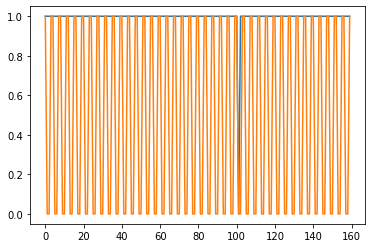

In [188]:
plt.plot(bpmxenbl_sofb)
plt.plot(bpmxenbl_fofb)

## Do BUMPS @ MANACA

In [62]:
angsx = np.array([-20, -2, 0, 2, 20])
angsy = np.array([-20, -2, 0, 2, 20])

In [218]:
# Configure phase

# Configure grid
# npoints = 11
# angsx = np.linspace(-20, 20, npoints)
# angsy = np.linspace(-20, 20, npoints)
# angsx = np.array([-10, -4, -2, 0, 2, 4, 10])
# angsy = np.array([-10, -4, -2, 0, 2, 4, 10])
# angsx = np.array([-4, 0, 4])
# angsy = np.array([-4, 0, 4])

angsx = np.linspace(-10, 10, 11)
angsy = np.linspace(-10, 10, 11)

# Select appropriate section and start measurement
stop_meas = False
pause_meas = False
subsec = '09SA'
xbpmlist = [xbpm_mnc1, xbpm_mnc2]
names = ['MNC1', 'MNC2']
t1 = threading.Thread(
    target=do_bumps,
    args=(
        angsx,
        angsy,
        subsec,
        idlist,
        currinfo,
        sofb,
        xbpmlist,
        names,
        bpmxenbl_sofb,
        bpmyenbl_sofb,
    )
)
t1.start()

Meas: (2/121)
agx:-10    agy:-10


Dorb max: 35.179 um
Waiting orbit...
    rms_residue = 35.172 um
    rms_residue = 35.039 um
    rms_residue = 35.171 um
    rms_residue = 28.433 um
    rms_residue = 20.318 um
    rms_residue = 13.619 um
    rms_residue = 8.876 um
    rms_residue = 5.808 um
    rms_residue = 3.666 um
    rms_residue = 2.293 um
    rms_residue = 1.430 um
    rms_residue = 1.050 um
    rms_residue = 0.588 um
Done!
Meas time: 28.263225078582764
Meas: (3/121)
agx:-10    agy:-8
Waiting orbit...
    rms_residue = 5.176 um
    rms_residue = 4.772 um
    rms_residue = 4.688 um
    rms_residue = 3.799 um
    rms_residue = 2.605 um
    rms_residue = 1.922 um
    rms_residue = 1.472 um
    rms_residue = 0.959 um
Done!
Meas time: 20.720425605773926
Meas: (4/121)
agx:-10    agy:-6
Waiting orbit...
    rms_residue = 5.058 um
    rms_residue = 5.029 um
    rms_residue = 4.841 um
    rms_residue = 3.660 um
    rms_residue = 2.449 um
    rms_residue = 1.817 um
    rms_residue = 1.199 um
    rms_residue = 0.982 um
Don

In [216]:
(11*11 -121)*20/60


0.0

# Do bumps @ MOGNO

In [220]:
pause_meas = False

In [221]:
# Configure grid
# angsx = np.array([0])
# angsy = np.linspace(-20, 20, 41)

angsx = np.array([0, ])
angsy = np.linspace(-20, 20, 11)

# Select appropriate section and start measurement
stop_meas = False
pause_meas = False
subsec = '10BC'
xbpmlist = [xbpm_mgn1, xbpm_mgn2]
names = ['MGN1', 'MGN2']
t1 = threading.Thread(
    target=do_bumps,
    args=(
        angsx,
        angsy,
        subsec,
        idlist,
        currinfo,
        sofb,
        xbpmlist,
        names,
        bpmxenbl_sofb,
        bpmyenbl_sofb
    )
)
t1.start()

Meas: (2/11)
agx:0    agy:-20


Dorb max: 36.18585005653392 um
Waiting orbit...
    rms_residue = 18.210 um
    rms_residue = 18.154 um
    rms_residue = 16.876 um
    rms_residue = 12.702 um
    rms_residue = 8.660 um
    rms_residue = 5.836 um
    rms_residue = 3.877 um
    rms_residue = 2.593 um
    rms_residue = 1.703 um
    rms_residue = 1.117 um
    rms_residue = 0.740 um
Done!
Meas time: 70.27173805236816
Meas: (3/11)
agx:0    agy:-16
Waiting orbit...
    rms_residue = 3.564 um
    rms_residue = 3.613 um
    rms_residue = 3.441 um
    rms_residue = 2.551 um
    rms_residue = 1.710 um
    rms_residue = 1.079 um
    rms_residue = 0.673 um
Done!
Meas time: 63.49041986465454
Meas: (4/11)
agx:0    agy:-12
Waiting orbit...
    rms_residue = 3.567 um
    rms_residue = 3.661 um
    rms_residue = 3.520 um
    rms_residue = 2.684 um
    rms_residue = 1.851 um
    rms_residue = 1.150 um
    rms_residue = 0.727 um
Done!
Meas time: 63.154335498809814
Meas: (5/11)
agx:0    agy:-8
Waiting orbit...
    rms_residue = 3.602 um


In [40]:
subsec = '06SB'
implement_bump(sofb=sofb, subsec=subsec, psx=0, psy=0, 
                    bpmxenbl=bpmxenbl, bpmyenbl=bpmyenbl)

Waiting orbit...
    rms_residue = 0.447 um
Done!


In [32]:
for i, xbpm in enumerate(xbpmlist):
    print(xbpm.prefix)

SI-10BCFE:DI-PBPM-1
SI-10BCFE:DI-PBPM-2


# Do bumps @ CARNAUBA

In [121]:
xbpm_cnb.ampB()

(50.16326980536445, 'fA')

In [105]:
xbpm_mgn1.ampA()

(8464, 0)

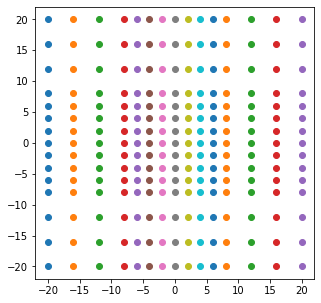

In [207]:
angsy_center = np.linspace(-8, 8, 9)
angsy_bound = np.linspace(12, 20, 3)
angsy = np.concatenate((-1*angsy_bound[::-1], angsy_center, angsy_bound))

angsx = np.copy(angsy)

x, y = np.meshgrid(angsx, angsy)
plt.figure(figsize=(5, 5))
plt.plot(x, y, 'o')



In [209]:
np.linspace(-10, 10, 11)

array([-10.,  -8.,  -6.,  -4.,  -2.,   0.,   2.,   4.,   6.,   8.,  10.])

In [208]:
np.diff(angsy_center)

array([2., 2., 2., 2., 2., 2., 2., 2.])

Waiting orbit...
    rms_residue = 3.590 um
    rms_residue = 3.650 um
    rms_residue = 3.394 um
    rms_residue = 2.453 um
    rms_residue = 1.692 um
    rms_residue = 1.081 um
    rms_residue = 0.728 um
Done!
Meas time: 62.771899938583374
Meas: (16/33)
agx:0    agy:8
Waiting orbit...
    rms_residue = 3.660 um
    rms_residue = 3.662 um
    rms_residue = 3.386 um
    rms_residue = 2.628 um
    rms_residue = 1.841 um
    rms_residue = 1.221 um
    rms_residue = 0.827 um
Done!
Meas time: 62.738600730895996
Meas: (17/33)
agx:0    agy:4
Waiting orbit...
    rms_residue = 3.577 um
    rms_residue = 3.569 um
    rms_residue = 3.443 um
    rms_residue = 2.624 um
    rms_residue = 1.863 um
    rms_residue = 1.258 um
    rms_residue = 0.855 um
Done!
Meas time: 63.50284719467163
Meas: (18/33)
agx:0    agy:-0
Waiting orbit...
    rms_residue = 3.670 um
    rms_residue = 3.653 um
    rms_residue = 3.425 um
    rms_residue = 2.505 um
    rms_residue = 1.678 um
    rms_residue = 1.098 um
    rms_

In [206]:
(11)**2 *20/60

40.333333333333336

    rms_residue = 3.610 um
    rms_residue = 3.554 um
    rms_residue = 2.930 um
    rms_residue = 1.970 um
    rms_residue = 1.258 um
    rms_residue = 0.812 um
Done!
Meas time: 63.8027138710022
Meas: (13/33)
agx:0    agy:20
Waiting orbit...
    rms_residue = 3.253 um
    rms_residue = 3.318 um
    rms_residue = 3.028 um
    rms_residue = 2.172 um
    rms_residue = 1.894 um
    rms_residue = 1.254 um
    rms_residue = 0.839 um
Done!
Meas time: 62.731629610061646
Meas: (14/33)
agx:0    agy:16
Waiting orbit...
    rms_residue = 3.462 um
    rms_residue = 3.517 um
    rms_residue = 3.146 um
    rms_residue = 2.377 um
    rms_residue = 1.734 um
    rms_residue = 1.175 um
    rms_residue = 0.819 um
Done!
Meas time: 62.59918808937073
Meas: (15/33)
agx:0    agy:12


In [70]:
# Configure gap
# gap = 0
# move_vpu_gap(vpu, gap)

# Configure grid
# angsx = np.array([0])
# angsy = np.linspace(-4, 4, 3)

# Select appropriate section and start measurement

angsx = np.array([-10, -8, 8, 10])
angsy = np.array([-10, 10])


stop_meas = False
pause_meas = False
subsec = '06SB'
xbpmlist = [xbpm_cnb]
names = ['CNB']
t1 = threading.Thread(target=do_bumps, args=(angsx, angsy, subsec, idlist, currinfo, sofb, xbpmlist, names, bpmxenbl, bpmyenbl))
t1.start()

Meas: (2/8)
agx:-10    agy:-10


Waiting orbit...
    rms_residue = 30.808 um
    rms_residue = 30.782 um
    rms_residue = 3.614 um
Done!
Meas time: 19.953986644744873
Meas: (3/8)
agx:-10    agy:10
Waiting orbit...
    rms_residue = 4.584 um
    rms_residue = 4.584 um
    rms_residue = 4.584 um
Done!
Meas time: 21.569299936294556
Meas: (4/8)
agx:-8    agy:10
Waiting orbit...
    rms_residue = 5.342 um
    rms_residue = 5.342 um
    rms_residue = 0.570 um
Done!
Meas time: 19.488621950149536
Meas: (5/8)
agx:-8    agy:-10
Waiting orbit...
    rms_residue = 43.188 um
    rms_residue = 43.188 um
    rms_residue = 3.387 um
Done!
Meas time: 23.49905562400818
Meas: (6/8)
agx:8    agy:-10
Waiting orbit...
    rms_residue = 1.951 um
Done!
Meas time: 19.504618644714355
Meas: (7/8)
agx:8    agy:10
Waiting orbit...
    rms_residue = 43.721 um
    rms_residue = 1.017 um
Done!
Meas time: 25.28632950782776
Meas: (8/8)
agx:10    agy:10
Waiting orbit...
    rms_residue = 4.580 um
    rms_residue = 4.580 um
    rms_residue = 4.580 um
D

In [53]:
restore_sofb_reforb(sofb, bpmxenbl, bpmyenbl)

# Do bumps @ CATERETE

In [ ]:
# Configure grid
# angsx = np.array([0])
# angsy = np.linspace(-20, 20, 41)

angsx = np.array([-10, -8, 8, 10])
angsy = np.array([-10, 10])

# Select appropriate section and start measurement
stop_meas = False
pause_meas = False
subsec = '07SP'
xbpmlist = [xbpm_cat]
names = ['CAT1']
t1 = threading.Thread(target=do_bumps, args=(angsx, angsy, subsec, idlist, currinfo, sofb, xbpmlist, names, bpmxenbl, bpmyenbl))
t1.start()

# Debug bump with SOFB on

In [190]:
subsec = '07SP'

agx = 0
agy = 0

implement_bump(
    sofb=sofb,
    subsec=subsec,
    agx=agx,
    agy=agy,
    bpmxenbl_sofb=bpmxenbl_sofb,
    bpmyenbl_sofb=bpmyenbl_sofb,
    tol_orb=1,
    # bpmxenbl_fofb=bpmxenbl_fofb,
    # bpmyenbl_fofb=bpmyenbl_fofb,
)


Waiting orbit...
    rms_residue = 0.222 um
Done!


In [164]:
sofb.bpmxenbl = bpmxenbl_sofb
sofb.bpmyenbl = bpmyenbl_sofb


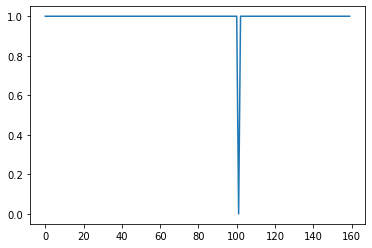

In [165]:
plt.plot(bpmyenbl_sofb)

In [37]:
6841042 * 2

13682084

Waiting orbit...
    rms_residue = 0.820 um
Done!
agx:0    agy:-1
Waiting orbit...
    rms_residue = 0.096 um
Done!
agx:0    agy:0
Waiting orbit...
    rms_residue = 0.096 um
Done!
agx:0    agy:1
Waiting orbit...
    rms_residue = 0.192 um
Done!
agx:0    agy:2
Waiting orbit...
    rms_residue = 0.524 um
Done!
agx:0    agy:3
Waiting orbit...
    rms_residue = 0.698 um
Done!
agx:0    agy:4
Waiting orbit...
    rms_residue = 0.251 um
Done!
agx:0    agy:5
Waiting orbit...
    rms_residue = 1.127 um
Done!
agx:0    agy:6
Waiting orbit...
    rms_residue = 0.583 um
Done!
agx:0    agy:7
Waiting orbit...
    rms_residue = 0.112 um
Done!
agx:0    agy:8
Waiting orbit...
    rms_residue = 0.343 um
Done!
agx:0    agy:9
Waiting orbit...
    rms_residue = 0.592 um
Done!
agx:0    agy:10
Waiting orbit...
    rms_residue = 0.209 um
Done!
agx:0    agy:11
Waiting orbit...
    rms_residue = 0.202 um
Done!
agx:0    agy:12
Waiting orbit...
    rms_residue = 0.362 um
Done!
agx:0    agy:13
Waiting orbit...
   